In [ ]:
# 1. 설치
!pip install transformers datasets scikit-learn accelerate -q

In [ ]:
# 2. 데이터 + 함수 정의
import torch, json, os, numpy as np, pandas as pd
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import MinMaxScaler

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'디바이스: {device}')

if not os.path.exists('katfishnet'):
    os.system('git clone https://github.com/Shinwoo-Park/detecting_llm_generated_korean_text_through_linguistic_analysis.git katfishnet')

def load_jsonl(path):
    with open(path, 'r', encoding='utf-8') as f:
        return [json.loads(line) for line in f]

essay    = load_jsonl('katfishnet/katfish_dataset/essay.jsonl')
abstract = load_jsonl('katfishnet/katfish_dataset/abstract.jsonl')
poetry   = load_jsonl('katfishnet/katfish_dataset/poetry.jsonl')

df_essay    = pd.DataFrame(essay);    df_essay['genre']    = 'essay'
df_abstract = pd.DataFrame(abstract); df_abstract['genre'] = 'abstract'
df_poetry   = pd.DataFrame(poetry);   df_poetry['genre']   = 'poetry'
df_all = pd.concat([df_essay, df_abstract, df_poetry]).reset_index(drop=True)

human_df = df_all[df_all['label'] == 0]
human_test = human_df.sample(frac=0.2, random_state=42)
llm_df = df_all[
    (df_all['label'] == 1) &
    (~df_all['written_by'].str.contains('gpt', case=False, na=False))
]

def compute_features(text, m_obs, tok_obs, m_per, tok_per, device, max_length=256):
    inp_o = tok_obs(text, return_tensors='pt', truncation=True, max_length=max_length).to(device)
    inp_p = tok_per(text, return_tensors='pt', truncation=True, max_length=max_length).to(device)
    inp_o2 = tok_obs(text, return_tensors='pt', truncation=True, max_length=max_length).to(device)
    with torch.no_grad():
        loss_o = m_obs(**inp_o, labels=inp_o['input_ids']).loss.item()
        logits_o = m_obs(**inp_o2).logits
        logits_p = m_per(**inp_p).logits
    seq_len = min(logits_o.shape[1], logits_p.shape[1]) - 1
    if seq_len <= 0:
        return {'bino': 0.0, 'nll_std': 0.0}
    lo = logits_o[:, :seq_len, :]
    lp = logits_p[:, :seq_len, :]
    v = min(lo.shape[-1], lp.shape[-1])
    lo, lp = lo[..., :v], lp[..., :v]

    ce = -(torch.softmax(lp[0], dim=-1) * torch.log_softmax(lo[0], dim=-1)).sum(-1)
    bino = loss_o / (ce.mean().item() + 1e-10)

    ids = inp_o['input_ids'][0, 1:seq_len+1]
    log_probs = torch.log_softmax(lo[0], dim=-1)
    nll = -log_probs[torch.arange(seq_len, device=device), ids]
    nll_std = nll.cpu().float().numpy().std()

    return {'bino': bino, 'nll_std': nll_std}

print(f"Human 테스트셋: {len(human_test)}, LLM: {len(llm_df)}")

디바이스: cuda
Human 테스트셋: 94, LLM: 1154


In [ ]:
# 3. Qwen 로드
tok_q1 = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B")
m_q1 = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-3B", torch_dtype=torch.float16, device_map="auto")
m_q1.eval()
tok_q2 = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B-Instruct")
m_q2 = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-3B-Instruct", torch_dtype=torch.float16, device_map="auto")
m_q2.eval()
print("Qwen 로드 완료")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/683 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen 로드 완료


In [ ]:
# 4. 피처 추출 (Human + LLM 전체)
all_feats = []
all_labels = []
all_writers = []
all_genres = []

total_h = len(human_test)
for i, (_, row) in enumerate(human_test.iterrows()):
    f = compute_features(row['text'], m_q1, tok_q1, m_q2, tok_q2, device)
    all_feats.append(f)
    all_labels.append(0)
    all_writers.append('Human')
    all_genres.append(row['genre'])
    print(f"\rHuman: {i+1}/{total_h}", end="")
print(" ✓")

total_l = len(llm_df)
for i, (_, row) in enumerate(llm_df.iterrows()):
    f = compute_features(row['text'], m_q1, tok_q1, m_q2, tok_q2, device)
    all_feats.append(f)
    all_labels.append(1)
    all_writers.append(row['written_by'])
    all_genres.append(row['genre'])
    print(f"\rLLM: {i+1}/{total_l}", end="")
print(" ✓")

feat_df = pd.DataFrame(all_feats)
feat_df['label'] = all_labels
feat_df['writer'] = all_writers
feat_df['genre'] = all_genres
print(f"\n총 {len(feat_df)}개")

Human: 94/94 ✓
LLM: 1154/1154 ✓

총 1248개


In [ ]:
# 5. Multiplicative Calibration 비교
h_mask = feat_df['label'] == 0
h_std_mean = feat_df[h_mask]['nll_std'].mean()
h_std_std = feat_df[h_mask]['nll_std'].std()
print(f"Human nll_std: mean={h_std_mean:.4f}, std={h_std_std:.4f}")

# z-score (Human 기준, AI일수록 음수)
feat_df['z_std'] = (feat_df['nll_std'] - h_std_mean) / h_std_std

# Norm(Bino) - 높을수록 AI
feat_df['norm_bino'] = MinMaxScaler().fit_transform(-feat_df[['bino']]).flatten()
feat_df['norm_std'] = MinMaxScaler().fit_transform(-feat_df[['nll_std']]).flatten()

labels = feat_df['label'].values

print(f"\n=== Multiplicative Calibration ===")
print(f"{'Method':<35} {'AUC':>8} {'Δ':>8}")
print("-" * 53)

auc_base = roc_auc_score(labels, feat_df['norm_bino']) * 100
print(f"{'Norm(Bino) only':<35} {auc_base:>8.2f} {0:>+8.2f}")

print(f"\n--- Linear: Norm(B) · (1 - λ·z) ---")
for lam in [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]:
    score = feat_df['norm_bino'] * (1 - lam * feat_df['z_std'])
    auc = roc_auc_score(labels, score) * 100
    print(f"{f'  λ = {lam}':<35} {auc:>8.2f} {auc-auc_base:>+8.2f}")

print(f"\n--- Exp: Norm(B) · exp(-λ·z) ---")
for lam in [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]:
    score = feat_df['norm_bino'] * np.exp(-lam * feat_df['z_std'])
    auc = roc_auc_score(labels, score) * 100
    print(f"{f'  λ = {lam}':<35} {auc:>8.2f} {auc-auc_base:>+8.2f}")

print(f"\n--- 기존 가중 평균 (참고) ---")
score_old = 0.4 * feat_df['norm_bino'] + 0.6 * feat_df['norm_std']
auc_old = roc_auc_score(labels, score_old) * 100
print(f"{'  0.4·Bino + 0.6·Std':<35} {auc_old:>8.2f} {auc_old-auc_base:>+8.2f}")

Human nll_std: mean=2.4086, std=0.3138

=== Multiplicative Calibration ===
Method                                   AUC        Δ
-----------------------------------------------------
Norm(Bino) only                        85.71    +0.00

--- Linear: Norm(B) · (1 - λ·z) ---
  λ = 0.1                              87.07    +1.36
  λ = 0.2                              87.60    +1.90
  λ = 0.3                              87.88    +2.17
  λ = 0.5                              88.01    +2.30
  λ = 0.7                              87.99    +2.28
  λ = 1.0                              87.91    +2.20

--- Exp: Norm(B) · exp(-λ·z) ---
  λ = 0.1                              87.13    +1.42
  λ = 0.2                              87.72    +2.01
  λ = 0.3                              88.03    +2.32
  λ = 0.5                              88.15    +2.44
  λ = 0.7                              88.10    +2.39
  λ = 1.0                              88.02    +2.31

--- 기존 가중 평균 (참고) ---
  0.4·Bino + 0.6·Std 

In [ ]:
# LLM별 정식 평가
feat_df['score_calib'] = feat_df['norm_bino'] * np.exp(-0.5 * feat_df['z_std'])

print("=== LLM별 비교 ===")
print(f"{'LLM':<12} {'Bino':>8} {'Calib':>8} {'Δ':>8}")
print("-" * 40)

human_data = feat_df[feat_df['label'] == 0]
b_aucs, c_aucs = [], []

for llm_match, llm_disp in [('solar', 'Solar'), ('qwen', 'Qwen2'), ('llama', 'Llama3.1')]:
    ai = feat_df[(feat_df['label']==1) & (feat_df['writer'].str.contains(llm_match, case=False))]
    subset = pd.concat([human_data, ai])
    lb = subset['label'].values
    auc_b = roc_auc_score(lb, subset['norm_bino'].values) * 100
    auc_c = roc_auc_score(lb, subset['score_calib'].values) * 100
    b_aucs.append(auc_b); c_aucs.append(auc_c)
    print(f"{llm_disp:<12} {auc_b:>8.2f} {auc_c:>8.2f} {auc_c-auc_b:>+8.2f}")
print("-" * 40)
print(f"{'평균':<12} {np.mean(b_aucs):>8.2f} {np.mean(c_aucs):>8.2f} {np.mean(c_aucs)-np.mean(b_aucs):>+8.2f}")

print(f"\n=== 장르별 비교 ===")
print(f"{'Genre':<12} {'Bino':>8} {'Calib':>8} {'Δ':>8}")
print("-" * 40)
for genre in ['essay', 'abstract', 'poetry']:
    subset = feat_df[feat_df['genre'] == genre]
    if subset['label'].nunique() < 2:
        continue
    lb = subset['label'].values
    auc_b = roc_auc_score(lb, subset['norm_bino'].values) * 100
    auc_c = roc_auc_score(lb, subset['score_calib'].values) * 100
    print(f"{genre:<12} {auc_b:>8.2f} {auc_c:>8.2f} {auc_c-auc_b:>+8.2f}")

=== LLM별 비교 ===
LLM              Bino    Calib        Δ
----------------------------------------
Solar           89.45    88.85    -0.59
Qwen2           82.79    88.54    +5.75
Llama3.1        84.31    86.81    +2.50
----------------------------------------
평균              85.52    88.07    +2.55

=== 장르별 비교 ===
Genre            Bino    Calib        Δ
----------------------------------------
essay           94.98    97.91    +2.93
abstract        56.53    48.96    -7.56
poetry          86.84    92.82    +5.98


In [ ]:
# Gated Fusion 실험
# w(X) = 1 - σ(γ · |D(X) - μ|)  → D가 평균에서 멀수록 D 가중치 높음
# 반대 방향: w(X) = σ(γ · |D(X) - μ|) → D가 평균에서 멀수록 B 가중치 높음
# S(X) = w·Norm(B) + (1-w)·Norm(D)

from scipy.special import expit  # sigmoid

labels = feat_df['label'].values

B_norm = feat_df['norm_bino'].values
D_norm = feat_df['norm_std'].values

D = feat_df['nll_std'].values
mu = D.mean()

print("=== Gated Fusion: Sigmoid Gate ===")
print(f"{'Method':<35} {'AUC':>8} {'Δ vs bino':>10}")
print("-" * 55)

auc_base = roc_auc_score(labels, B_norm) * 100
print(f"{'Norm(Bino) only':<35} {auc_base:>8.2f} {0:>+10.2f}")

# γ 탐색
print(f"\n--- w(X) = 1 - σ(γ · |D(X) - μ|) ---")
for gamma in [0.3, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0]:
    w = 1 - expit(gamma * np.abs(D - mu))
    score = w * B_norm + (1 - w) * D_norm
    auc = roc_auc_score(labels, score) * 100
    print(f"{f'  γ = {gamma}':<35} {auc:>8.2f} {auc-auc_base:>+10.2f}")

# 반대 방향도: w(X) = σ(γ · |D(X) - μ|)  → |z| 클수록 w 큼 (B 가중치 높음)
print(f"\n--- w(X) = σ(γ · |D(X) - μ|) (반대 방향) ---")
for gamma in [0.3, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0]:
    w = expit(gamma * np.abs(D - mu))
    score = w * B_norm + (1 - w) * D_norm
    auc = roc_auc_score(labels, score) * 100
    print(f"{f'  γ = {gamma}':<35} {auc:>8.2f} {auc-auc_base:>+10.2f}")

# 비교용
print(f"\n--- 참고 ---")
score_calib = feat_df['norm_bino'] * np.exp(-0.5 * feat_df['z_std'])
auc_calib = roc_auc_score(labels, score_calib) * 100
print(f"{'Calibration (Exp, λ=0.5)':<35} {auc_calib:>8.2f} {auc_calib-auc_base:>+10.2f}")

score_avg = 0.4 * feat_df['norm_bino'] + 0.6 * feat_df['norm_std']
auc_avg = roc_auc_score(labels, score_avg) * 100
print(f"{'가중 평균 (0.4·B + 0.6·D)':<35} {auc_avg:>8.2f} {auc_avg-auc_base:>+10.2f}")

=== Gated Fusion: Sigmoid Gate ===
Method                                   AUC  Δ vs bino
-------------------------------------------------------
Norm(Bino) only                        85.71      +0.00

--- w(X) = 1 - σ(γ · |D(X) - μ|) ---
  γ = 0.3                              87.98      +2.27
  γ = 0.5                              87.98      +2.28
  γ = 1.0                              87.94      +2.23
  γ = 1.5                              87.88      +2.17
  γ = 2.0                              87.84      +2.13
  γ = 3.0                              87.70      +1.99
  γ = 5.0                              87.43      +1.72

--- w(X) = σ(γ · |D(X) - μ|) (반대 방향) ---
  γ = 0.3                              87.94      +2.23
  γ = 0.5                              87.92      +2.21
  γ = 1.0                              87.89      +2.18
  γ = 1.5                              87.84      +2.13
  γ = 2.0                              87.78      +2.08
  γ = 3.0                              87.64 

In [ ]:
# Gated Fusion 정식 평가 (γ=1.0)
gamma = 1.0
D = feat_df['nll_std'].values
mu = D.mean()

w = 1 - expit(gamma * np.abs(D - mu))
feat_df['score_gated'] = w * feat_df['norm_bino'].values + (1 - w) * feat_df['norm_std'].values

print("=== LLM별 비교 ===")
print(f"{'LLM':<12} {'Bino':>8} {'Calib':>8} {'Gated':>8} {'Δ Gated':>10}")
print("-" * 50)

human_data = feat_df[feat_df['label'] == 0]
b_aucs, c_aucs, g_aucs = [], [], []

for llm_match, llm_disp in [('solar', 'Solar'), ('qwen', 'Qwen2'), ('llama', 'Llama3.1')]:
    ai = feat_df[(feat_df['label']==1) & (feat_df['writer'].str.contains(llm_match, case=False))]
    subset = pd.concat([human_data, ai])
    lb = subset['label'].values
    auc_b = roc_auc_score(lb, subset['norm_bino'].values) * 100
    auc_c = roc_auc_score(lb, (subset['norm_bino'] * np.exp(-0.5 * subset['z_std'])).values) * 100
    auc_g = roc_auc_score(lb, subset['score_gated'].values) * 100
    b_aucs.append(auc_b); c_aucs.append(auc_c); g_aucs.append(auc_g)
    print(f"{llm_disp:<12} {auc_b:>8.2f} {auc_c:>8.2f} {auc_g:>8.2f} {auc_g-auc_b:>+10.2f}")
print("-" * 50)
print(f"{'평균':<12} {np.mean(b_aucs):>8.2f} {np.mean(c_aucs):>8.2f} {np.mean(g_aucs):>8.2f} {np.mean(g_aucs)-np.mean(b_aucs):>+10.2f}")

print(f"\n=== 장르별 비교 ===")
print(f"{'Genre':<12} {'Bino':>8} {'Calib':>8} {'Gated':>8} {'Δ Gated':>10}")
print("-" * 50)
for genre in ['essay', 'abstract', 'poetry']:
    subset = feat_df[feat_df['genre'] == genre]
    if subset['label'].nunique() < 2:
        continue
    lb = subset['label'].values
    auc_b = roc_auc_score(lb, subset['norm_bino'].values) * 100
    auc_c = roc_auc_score(lb, (subset['norm_bino'] * np.exp(-0.5 * subset['z_std'])).values) * 100
    auc_g = roc_auc_score(lb, subset['score_gated'].values) * 100
    print(f"{genre:<12} {auc_b:>8.2f} {auc_c:>8.2f} {auc_g:>8.2f} {auc_g-auc_b:>+10.2f}")

=== LLM별 비교 ===
LLM              Bino    Calib    Gated    Δ Gated
--------------------------------------------------
Solar           89.45    88.85    89.22      -0.23
Qwen2           82.79    88.54    87.65      +4.86
Llama3.1        84.31    86.81    86.65      +2.34
--------------------------------------------------
평균              85.52    88.07    87.84      +2.33

=== 장르별 비교 ===
Genre            Bino    Calib    Gated    Δ Gated
--------------------------------------------------
essay           94.98    97.91    97.43      +2.45
abstract        56.53    48.96    50.09      -6.44
poetry          86.84    92.82    91.67      +4.83


In [ ]:
print("=== 장르별 |z_std| 분포 ===")

gamma = 1.0
D = feat_df['nll_std'].values
mu = D.mean()

for genre in ['essay', 'abstract', 'poetry']:
    subset = feat_df[feat_df['genre'] == genre]

    D_sub = subset['nll_std'].values
    abs_dev = np.abs(D_sub - mu)

    w_mean = (1 - expit(gamma * abs_dev)).mean()

    print(f"{genre:<12} |D-μ| mean = {abs_dev.mean():.4f}, "
          f"w mean = {w_mean.mean():.4f}")

=== 장르별 |z_std| 분포 ===
essay        |D-μ| mean = 0.2335, w mean = 0.4425
abstract     |D-μ| mean = 0.2797, w mean = 0.4312
poetry       |D-μ| mean = 0.1922, w mean = 0.4529


In [ ]:
# Qwen2.5-3B에서 각 메트릭의 abstract 성능
abstract_data = feat_df[feat_df['genre'] == 'abstract']
print(f"Abstract 데이터: Human {(abstract_data['label']==0).sum()}, AI {(abstract_data['label']==1).sum()}")

if abstract_data['label'].nunique() < 2:
    print("⚠️ Abstract에 클래스 부족")
else:
    lb = abstract_data['label'].values

    # 각 단일 메트릭
    print(f"\n{'Method':<25} {'AUC':>8}")
    print("-" * 35)

    auc_bino = roc_auc_score(lb, abstract_data['norm_bino'].values) * 100
    print(f"{'Bino only':<25} {auc_bino:>8.2f}")

    auc_std = roc_auc_score(lb, abstract_data['norm_std'].values) * 100
    print(f"{'NLL_std only':<25} {auc_std:>8.2f}")

    # 부호 반대도 시도 (혹시 abstract에서는 분포가 반대일 수 있음)
    auc_bino_rev = roc_auc_score(lb, -abstract_data['norm_bino'].values) * 100
    auc_std_rev = roc_auc_score(lb, -abstract_data['norm_std'].values) * 100
    print(f"{'Bino (반대 부호)':<25} {auc_bino_rev:>8.2f}")
    print(f"{'NLL_std (반대 부호)':<25} {auc_std_rev:>8.2f}")

    # 원본 raw 값으로도 확인
    auc_raw_bino = roc_auc_score(lb, -abstract_data['bino'].values) * 100
    auc_raw_std = roc_auc_score(lb, -abstract_data['nll_std'].values) * 100
    print(f"{'Raw bino (-)':<25} {auc_raw_bino:>8.2f}")
    print(f"{'Raw nll_std (-)':<25} {auc_raw_std:>8.2f}")

    # Calibration, Gated
    score_calib = abstract_data['norm_bino'] * np.exp(-0.5 * abstract_data['z_std'])
    auc_calib = roc_auc_score(lb, score_calib) * 100
    print(f"{'Calibration':<25} {auc_calib:>8.2f}")

# Human vs AI 평균값도 확인
print(f"\n=== Abstract Human vs AI 평균 ===")
print(abstract_data.groupby('label')[['bino', 'nll_std']].mean())

Abstract 데이터: Human 13, AI 178

Method                         AUC
-----------------------------------
Bino only                    56.53
NLL_std only                 43.78
Bino (반대 부호)                 43.47
NLL_std (반대 부호)              56.22
Raw bino (-)                 56.53
Raw nll_std (-)              43.78
Calibration                  48.96

=== Abstract Human vs AI 평균 ===
           bino   nll_std
label                    
0      1.073762  2.217205
1      1.049743  2.272735


In [ ]:
from sklearn.metrics import roc_auc_score, classification_report

# 1. 장르별 |D(X)-μ| 분포 자세히 보기
print("=== 장르별 |D(X)-μ| 분포 (label 무관) ===")
print(f"{'Genre':<12} {'count':>6} {'mean':>8} {'std':>8} {'min':>8} {'25%':>8} {'50%':>8} {'75%':>8} {'max':>8}")
print("-" * 78)

D_all = feat_df['nll_std'].values
mu = D_all.mean()

for genre in ['essay', 'abstract', 'poetry']:
    subset = feat_df[feat_df['genre'] == genre]
    abs_dev = np.abs(subset['nll_std'].values - mu)

    print(f"{genre:<12} {len(subset):>6} {abs_dev.mean():>8.3f} {abs_dev.std():>8.3f} "
          f"{abs_dev.min():>8.3f} {np.quantile(abs_dev, 0.25):>8.3f} {np.median(abs_dev):>8.3f} "
          f"{np.quantile(abs_dev, 0.75):>8.3f} {abs_dev.max():>8.3f}")

# 2. |D-μ|로 abstract vs not-abstract 이진 분류
print(f"\n=== |D-μ|로 abstract 식별 가능한가 ===")
is_abstract = (feat_df['genre'] == 'abstract').astype(int).values
abs_dev_all = np.abs(feat_df['nll_std'].values - mu)

# |D-μ|가 작을수록 abstract인지 확인하려면 부호 반전
auc_abstract = roc_auc_score(is_abstract, -abs_dev_all) * 100
print(f"AUC (|D-μ| → abstract): {auc_abstract:.2f}")

# 임계값별 정확도
print(f"\n{'Threshold':<14} {'Precision':>10} {'Recall':>10} {'F1':>8}")
print("-" * 44)

for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    pred_abstract = (abs_dev_all < t).astype(int)

    tp = ((pred_abstract == 1) & (is_abstract == 1)).sum()
    fp = ((pred_abstract == 1) & (is_abstract == 0)).sum()
    fn = ((pred_abstract == 0) & (is_abstract == 1)).sum()

    prec = tp / (tp + fp + 1e-10)
    rec = tp / (tp + fn + 1e-10)
    f1 = 2 * prec * rec / (prec + rec + 1e-10)

    print(f"|D-μ| < {t:<6} {prec*100:>10.2f} {rec*100:>10.2f} {f1*100:>8.2f}")

=== 장르별 |D(X)-μ| 분포 (label 무관) ===
Genre         count     mean      std      min      25%      50%      75%      max
------------------------------------------------------------------------------
essay           450    0.234    0.180    0.001    0.096    0.197    0.311    0.860
abstract        191    0.280    0.190    0.003    0.126    0.249    0.406    0.946
poetry          607    0.192    0.197    0.001    0.061    0.143    0.245    1.692

=== |D-μ|로 abstract 식별 가능한가 ===
AUC (|D-μ| → abstract): 37.43

Threshold       Precision     Recall       F1
--------------------------------------------
|D-μ| < 0.1          9.21      18.85    12.37
|D-μ| < 0.2         11.29      41.36    17.73
|D-μ| < 0.3         11.86      58.12    19.70
|D-μ| < 0.4         13.16      73.30    22.31
|D-μ| < 0.5         14.54      86.39    24.89


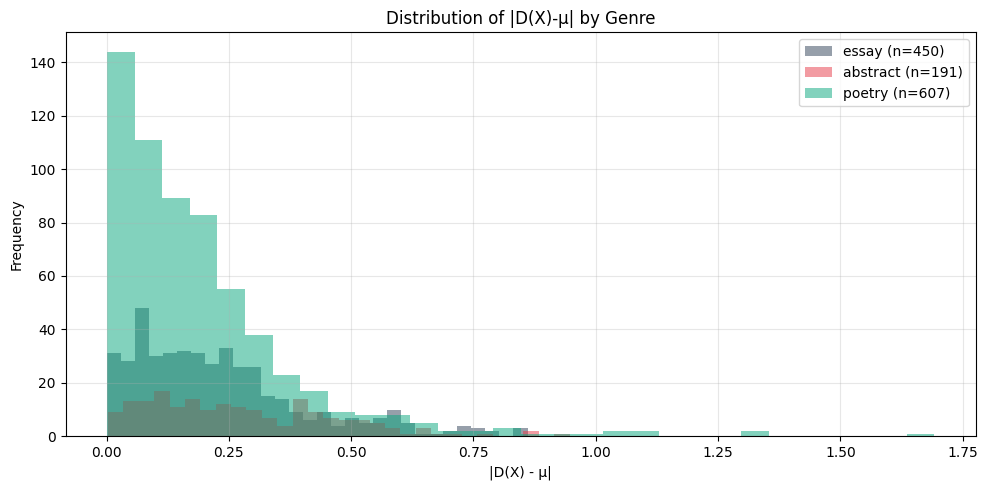

saved: deviation_distribution_by_genre.png


In [ ]:
# 3. 시각화: 장르별 |D(X)-μ| 분포 히스토그램
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

colors = {
    'essay': '#2E4057',
    'abstract': '#E63946',
    'poetry': '#06A77D'
}

D_all = feat_df['nll_std'].values
mu = D_all.mean()

for genre in ['essay', 'abstract', 'poetry']:
    subset = feat_df[feat_df['genre'] == genre]

    abs_dev = np.abs(subset['nll_std'].values - mu)

    ax.hist(
        abs_dev,
        bins=30,
        alpha=0.5,
        label=f'{genre} (n={len(subset)})',
        color=colors[genre]
    )

ax.set_xlabel('|D(X) - μ|')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of |D(X)-μ| by Genre')

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('deviation_distribution_by_genre.png', dpi=150)

plt.show()

print("saved: deviation_distribution_by_genre.png")

In [ ]:
# |D(X)-μ|가 작은 텍스트들이 어떤 장르인지 확인
D_all = feat_df['nll_std'].values
mu = D_all.mean()

abs_dev_all = np.abs(feat_df['nll_std'].values - mu)

print("=== |D-μ| < 0.2인 텍스트 분포 ===")
small_dev = feat_df[abs_dev_all < 0.2]
print(small_dev['genre'].value_counts())
print(f"\n총 {len(small_dev)}개")

print("\n=== |D-μ| < 0.4인 텍스트 분포 ===")
small_dev_04 = feat_df[abs_dev_all < 0.4]
print(small_dev_04['genre'].value_counts())
print(f"\n총 {len(small_dev_04)}개")

# 장르별로 |D-μ|가 작은 비율
print("\n=== 장르별 |D-μ| < 0.4 비율 ===")
for genre in ['essay', 'abstract', 'poetry']:
    subset = feat_df[feat_df['genre'] == genre]
    abs_dev = np.abs(subset['nll_std'].values - mu)
    small_ratio = (abs_dev < 0.4).mean() * 100
    print(f"{genre:<12} {small_ratio:.1f}%")

=== |D-μ| < 0.2인 텍스트 분포 ===
genre
poetry      390
essay       231
abstract     79
Name: count, dtype: int64

총 700개

=== |D-μ| < 0.4인 텍스트 분포 ===
genre
poetry      545
essay       379
abstract    140
Name: count, dtype: int64

총 1064개

=== 장르별 |D-μ| < 0.4 비율 ===
essay        84.2%
abstract     73.3%
poetry       89.8%


In [ ]:
# Hybrid Detector: |D-μ| < threshold면 Bino만, 아니면 Gated 적용
print("=== Hybrid Detector ===")
print(f"{'Threshold':<14} {'Total AUC':>10} {'Essay':>8} {'Abstract':>10} {'Poetry':>8}")
print("-" * 52)

labels = feat_df['label'].values
B_norm = feat_df['norm_bino'].values
D_norm = feat_df['norm_std'].values

gamma = 1.0
D = feat_df['nll_std'].values
mu = D.mean()
abs_dev = np.abs(D - mu)

# 수정된 Gated 스코어
w = 1 - expit(gamma * abs_dev)
gated_score = w * B_norm + (1 - w) * D_norm

for thresh in [0.1, 0.2, 0.3, 0.4, 0.5]:
    # |D-μ| < thresh면 Bino만
    # |D-μ| >= thresh면 Gated 사용
    use_bino_only = abs_dev < thresh

    hybrid_score = np.where(
        use_bino_only,
        B_norm,
        gated_score
    )

    auc_total = roc_auc_score(labels, hybrid_score) * 100

    aucs = {}
    for g in ['essay', 'abstract', 'poetry']:
        mask = (feat_df['genre'] == g).values
        if feat_df.loc[mask, 'label'].nunique() < 2:
            aucs[g] = 0
            continue
        aucs[g] = roc_auc_score(labels[mask], hybrid_score[mask]) * 100

    print(f"|D-μ| < {thresh:<5} {auc_total:>10.2f} {aucs['essay']:>8.2f} {aucs['abstract']:>10.2f} {aucs['poetry']:>8.2f}")

# 비교: 순수 Gated, 순수 Bino
print("\n--- 비교 ---")

auc_g = roc_auc_score(labels, gated_score) * 100
auc_b = roc_auc_score(labels, B_norm) * 100

aucs_g = {}
aucs_b = {}

for g in ['essay', 'abstract', 'poetry']:
    mask = (feat_df['genre'] == g).values
    if feat_df.loc[mask, 'label'].nunique() < 2:
        aucs_g[g] = aucs_b[g] = 0
        continue

    aucs_g[g] = roc_auc_score(labels[mask], gated_score[mask]) * 100
    aucs_b[g] = roc_auc_score(labels[mask], B_norm[mask]) * 100

print(f"{'Gated only':<14} {auc_g:>10.2f} {aucs_g['essay']:>8.2f} {aucs_g['abstract']:>10.2f} {aucs_g['poetry']:>8.2f}")
print(f"{'Bino only':<14} {auc_b:>10.2f} {aucs_b['essay']:>8.2f} {aucs_b['abstract']:>10.2f} {aucs_b['poetry']:>8.2f}")

=== Hybrid Detector ===
Threshold       Total AUC    Essay   Abstract   Poetry
----------------------------------------------------
|D-μ| < 0.1        84.77    91.29      56.35    87.06
|D-μ| < 0.2        82.39    88.89      54.24    85.27
|D-μ| < 0.3        82.94    92.09      59.46    82.83
|D-μ| < 0.4        84.83    94.11      56.31    85.25
|D-μ| < 0.5        85.56    94.90      54.49    86.57

--- 비교 ---
Gated only          87.94    97.43      50.09    91.67
Bino only           85.71    94.98      56.53    86.84
